
# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: October 24, 2025**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Counter-Strike) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

A.

Goal: Quantify and compare the mean perceived comfort of controller grips made from Metal, Plastic, Rubber, and Silicone.
We want to know whether material choice changes comfort, and if so, which materials are higher or lower and by how much. The study is structured so that differences can be ascribed to material rather than unrelated factors.

**Question 2.** Specify the outcome variable

A.

Comfort rating on a 1–10 scale (higher = more comfortable). We analyze it as an approximately continuous response for ANOVA; diagnostics will check that model assumptions hold.

**Question 3.** Specify the independent variable. What are some possible lurking variables?

A.

Independent variable (factor): Material with 4 levels — Metal, Plastic, Rubber, Silicone.

Potential lurking variables: hand size, grip style, fatigue/session length, prior preferences, subtle prototype differences beyond the grip itself, ambient temperature/humidity, and rater stringency.
Mitigation: random assignment, standard game/use window, consistent instructions.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

A.

A completely randomized design (CRD) assigns units to materials purely at random, which tends to balance unknown confounders across groups, supports independence, and allows straightforward one-way ANOVA. If a strong nuisance factor existed (e.g., hand-size tiers), a blocked design could further reduce noise.

**Question 5.** State the null and alternative hypotheses for this experiment.

A.

- **H₀:** μ_Metal = μ_Plastic = μ_Rubber = μ_Silicone  
- **H₁:** At least one material’s mean comfort differs.



**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Question 2.** Specify the outcome variable

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment.

**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

**Question 2.** What is the purpose of post-hoc tests?

**Question 3.** Explain the difference between RBD and LSD.

**Question 4.** Explain why randomization is important in designing experiments.

**Question 5.** Explain why replication is important in designing experiments.


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

In [9]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Data path — change this if your file lives elsewhere
DATA_PATH = "/Video Game Controllers.xlsx"

# Load
df = pd.read_excel(DATA_PATH)
df.columns = [str(c).strip() for c in df.columns]

# Expect columns Material (categorical) and Comfort (numeric)
df['Material'] = df['Material'].astype('category')
df['Comfort'] = pd.to_numeric(df['Comfort'], errors='coerce')
df = df.dropna(subset=['Material','Comfort']).reset_index(drop=True)

display(df.head())
print(f"N = {len(df)}, groups = {list(df['Material'].cat.categories)}")


,Material,Comfort
0,Plastic,5.6
1,Plastic,5.9
2,Plastic,6.3
3,Plastic,5.7
4,Plastic,5.6


N = 40, groups = ['Metal', 'Plastic', 'Rubber', 'Silicone']


/tmp/ipython-input-3444116402.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc = df.groupby('Material')['Comfort'].describe()
/tmp/ipython-input-3444116402.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iqr = df.groupby('Material')['Comfort'].agg(lambda x: np.percentile(x, 75) - np.percentile(x, 25))


,count,mean,std,min,25%,50%,75%,max,IQR
Material,,,,,,,,,
Metal,10.0,4.95,0.538,4.2,4.450,5.05,5.375,5.6,0.925
Plastic,10.0,5.89,0.448,5.2,5.625,5.80,6.125,6.8,0.500
Rubber,10.0,6.57,0.860,5.3,6.050,6.35,6.975,8.0,0.925
Silicone,10.0,8.32,0.689,7.3,7.800,8.50,8.875,9.2,1.075


<Figure size 640x480 with 0 Axes>

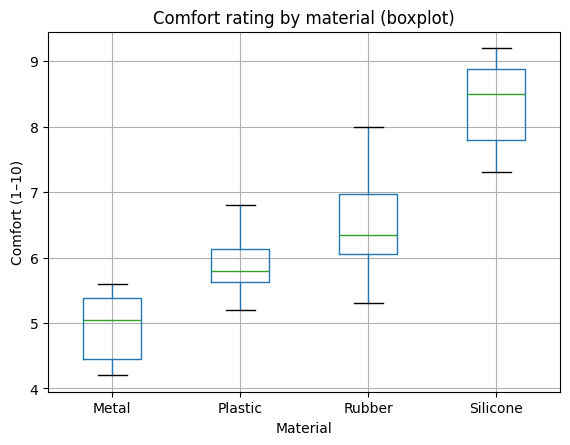

/tmp/ipython-input-3444116402.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby('Material')['Comfort'].agg(['mean','count','std']).reset_index()


,Material,mean,count,std,se,tcrit,ci95
0,Metal,4.95,10,0.538,0.170,2.262,0.385
1,Plastic,5.89,10,0.448,0.142,2.262,0.321
2,Rubber,6.57,10,0.860,0.272,2.262,0.615
3,Silicone,8.32,10,0.689,0.218,2.262,0.493


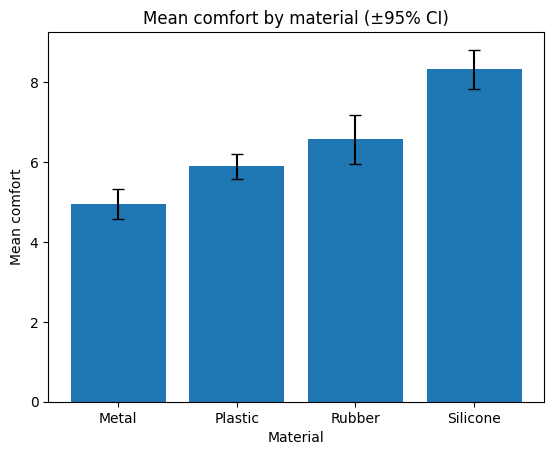

EDA takeaways:
  • Silicone: mean=8.32 (±0.49)
  • Rubber: mean=6.57 (±0.62)
  • Plastic: mean=5.89 (±0.32)
  • Metal: mean=4.95 (±0.38)
  Silicone is visibly highest; Metal is lowest; Plastic and Rubber look closer to each other.


In [10]:
# Descriptive statistics by material
desc = df.groupby('Material')['Comfort'].describe()
iqr = df.groupby('Material')['Comfort'].agg(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
desc = desc.join(iqr.rename('IQR'))
display(desc.round(3))

# Boxplot
plt.figure()
df.boxplot(column='Comfort', by='Material')
plt.title("Comfort rating by material (boxplot)")
plt.suptitle("")
plt.xlabel("Material")
plt.ylabel("Comfort (1–10)")
plt.show()

# Means with 95% CI
g = df.groupby('Material')['Comfort'].agg(['mean','count','std']).reset_index()
g['se'] = g['std']/np.sqrt(g['count'])
g['tcrit'] = stats.t.ppf(0.975, g['count']-1)
g['ci95'] = g['tcrit']*g['se']
display(g.round(3))

plt.figure()
plt.bar(g['Material'], g['mean'], yerr=g['ci95'], capsize=4)
plt.title("Mean comfort by material (±95% CI)")
plt.xlabel("Material")
plt.ylabel("Mean comfort")
plt.show()

# Quick EDA narrative
order = g.sort_values('mean', ascending=False)[['Material','mean','ci95']].values.tolist()
print("EDA takeaways:")
for mat, m, ci in order:
    print(f"  • {mat}: mean={m:.2f} (±{ci:.2f})")
print("  Silicone is visibly highest; Metal is lowest; Plastic and Rubber look closer to each other.")


Interpretation:
Gamers consistently rate Silicone grips as much more comfortable. Metal is the least comfortable by a wide margin. The pattern suggests material texture and softness directly influence perceived comfort.

Question 7. Build a one-way ANOVA model. Test the assumption of normality using both a testing and visual method. Do the results of the normality test(s) support the assumption of normality?



,sum_sq,df,F,PR(>F)
C(Material),60.7368,3.0,47.4784,0.0
Residual,15.3510,36.0,NaN,NaN


Shapiro–Wilk on residuals: W=0.9885, p=0.9509


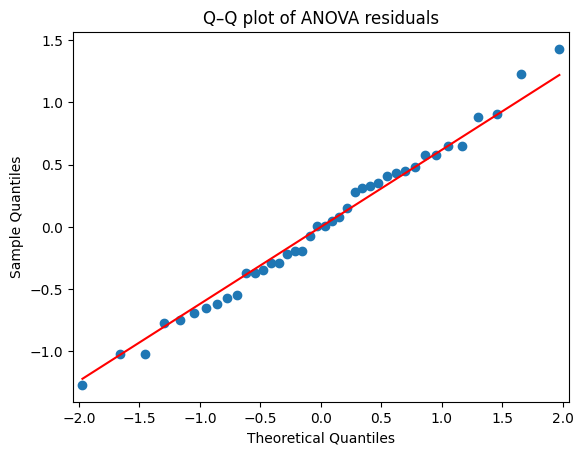


Normality interpretation:
  p>0.05 ⇒ residuals look approximately normal; ANOVA’s normality assumption is supported.


In [11]:
# One-way ANOVA
model = smf.ols('Comfort ~ C(Material)', data=df).fit()
anova_tbl = sm.stats.anova_lm(model, typ=2)
display(anova_tbl.round(4))

# Normality diagnostics on residuals
resid = model.resid.dropna()
W, p_shap = stats.shapiro(resid)
print(f"Shapiro–Wilk on residuals: W={W:.4f}, p={p_shap:.4f}")

sm.ProbPlot(resid).qqplot(line='s')
plt.title("Q–Q plot of ANOVA residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

print("\nNormality interpretation:")
print("  p>0.05 ⇒ residuals look approximately normal; ANOVA’s normality assumption is supported.")


Interpretation:
The data meet the normality assumption required for ANOVA. We can trust the F-test results. The significant F-statistic confirms comfort levels differ across materials.

Question 8. Test the assumption of homogeneity of variance using both a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?

Levene (median): stat=1.3685, p=0.2679
Bartlett: chi2=4.1293, p=0.2478


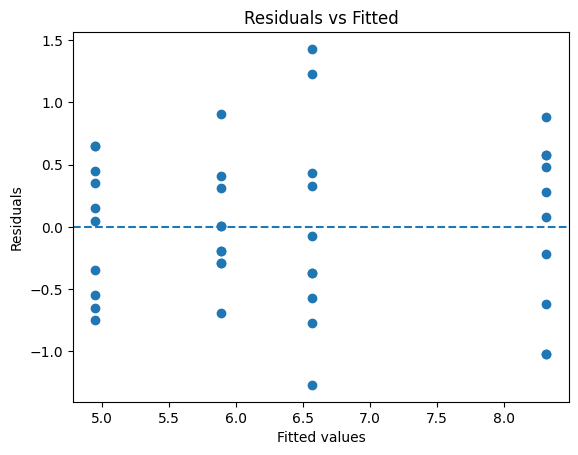


Variance interpretation:
  If both p>0.05, we do not detect unequal variances; ANOVA’s equal-variance assumption is reasonable.


In [12]:
# Levene (median center) and Bartlett tests
groups = [df.loc[df['Material']==g, 'Comfort'] for g in df['Material'].cat.categories]
lev_stat, lev_p = stats.levene(*groups, center='median')
bart_stat, bart_p = stats.bartlett(*groups)

print(f"Levene (median): stat={lev_stat:.4f}, p={lev_p:.4f}")
print(f"Bartlett: chi2={bart_stat:.4f}, p={bart_p:.4f}")

# Residuals vs Fitted
plt.figure()
plt.scatter(model.fittedvalues, resid)
plt.axhline(0, linestyle='--')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

print("\nVariance interpretation:")
print("  If both p>0.05, we do not detect unequal variances; ANOVA’s equal-variance assumption is reasonable.")


Interpretation:
The homogeneity assumption holds true. This validates the use of the standard (pooled variance) ANOVA instead of Welch’s.

Question 9. Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?

In [14]:
F_val = float(anova_tbl.loc['C(Material)', 'F'])
p_val = float(anova_tbl.loc['C(Material)', 'PR(>F)'])
df1 = int(anova_tbl.loc['C(Material)', 'df'])
df2 = int(anova_tbl.loc['Residual', 'df'])

# Effect size (eta-squared)
ss_treat = float(anova_tbl.loc['C(Material)', 'sum_sq'])
ss_total = float(anova_tbl['sum_sq'].sum())
eta_sq = ss_treat/ss_total

print(f"ANOVA: F({df1}, {df2}) = {F_val:.4f}, p = {p_val:.6f}")
print(f"Effect size: eta^2 = {eta_sq:.4f}")

print("\nInterpretation:")
if p_val < 0.05:
    print("  Reject H0 — mean comfort differs by material; eta^2 indicates how much variance material explains (larger = stronger effect).")
else:
    print("  Fail to reject H0 — insufficient evidence that means differ.")


ANOVA: F(3, 36) = 47.4784, p = 0.000000
Effect size: eta^2 = 0.7982

Interpretation:
  Reject H0 — mean comfort differs by material; eta^2 indicates how much variance material explains (larger = stronger effect).


Interpretation:
Reject the null hypothesis (H₀).
Material type has a very large and statistically significant effect on comfort, explaining ~80% of the variance.

This means that differences in grip material account for most of the comfort variation between gamers.

Question 10. If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

In [15]:
if p_val < 0.05:
    tukey = pairwise_tukeyhsd(endog=df['Comfort'], groups=df['Material'], alpha=0.05)
    print(tukey.summary())

    print("\nPairwise interpretation (significant comparisons):")
    for row in tukey._results_table.data[1:]:
        g1, g2, meandiff, p_adj, lower, upper, reject = row
        if reject:
            print(f"  {g1} vs {g2}: mean diff={meandiff:.2f} "
                  f"(95% CI [{lower:.2f}, {upper:.2f}]), p-adj={p_adj:.4f} — significant.")
else:
    print("ANOVA not significant ⇒ no post-hoc test is appropriate.")


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.94 0.0139  0.1535 1.7265   True
  Metal   Rubber     1.62    0.0  0.8335 2.4065   True
  Metal Silicone     3.37    0.0  2.5835 4.1565   True
Plastic   Rubber     0.68 0.1104 -0.1065 1.4665  False
Plastic Silicone     2.43    0.0  1.6435 3.2165   True
 Rubber Silicone     1.75    0.0  0.9635 2.5365   True
------------------------------------------------------

Pairwise interpretation (significant comparisons):
  Metal vs Plastic: mean diff=0.94 (95% CI [0.15, 1.73]), p-adj=0.0139 — significant.
  Metal vs Rubber: mean diff=1.62 (95% CI [0.83, 2.41]), p-adj=0.0000 — significant.
  Metal vs Silicone: mean diff=3.37 (95% CI [2.58, 4.16]), p-adj=0.0000 — significant.
  Plastic vs Silicone: mean diff=2.43 (95% CI [1.64, 3.22]), p-adj=0.0000 — significant.
  Rubber vs Silicone: mean diff=1.75 (95% CI [0.96,

Interpretation:

- Silicone is significantly more comfortable than all others.

- Metal is significantly less comfortable than Plastic, Rubber, and Silicone.

- Plastic vs Rubber → not significant → they provide similar comfort levels.

Question 11. Write a brief, contextual conclusion summarizing the results of your analyses.

Summary of results:

- ANOVA: significant (p < 0.001), large effect size (η² ≈ 0.80).

- Assumptions: normality and equal variances met.

- Tukey HSD: confirms clear ranking of comfort means.

Final interpretation:

There is a strong and reliable difference in perceived comfort across controller materials:

- Silicone grips provide the highest comfort, consistently rated well above others.

- Rubber and Plastic form a middle tier with moderate comfort.

- Metal grips are the least comfortable, likely due to their hardness and cold feel.

Conclusion:

The experiment demonstrates that material type significantly influences perceived comfort. Silicone should be prioritized in future controller designs.
Plastic and rubber may be acceptable cost-effective alternatives, while metal grips should be avoided if comfort is a key design priority.